# Uji Statistik Perbandingan RF vs SVM

**Alur:**
1. Load model dan data uji
2. Hitung error prediksi per model
3. Uji normalitas (Shapiro-Wilk)
4. Uji statistik (uji-t atau Mann-Whitney sesuai hasil normalitas)
5. Interpretasi hasil

**Jalankan sel secara berurutan: SEL 1 → 2 → 3 → 4 → 5**

## SEL 1 – Install dan import library

In [ ]:
!pip install scikit-learn==1.6.1 scipy joblib pandas numpy matplotlib seaborn --quiet
print('Install selesai.')

Install selesai.


## SEL 2 – Load model dan data uji

Upload file berikut ke Colab:
- model_rf_prediksi.pkl
- model_svm_regresi.pkl
- scaler_svm_regresi.pkl
- data_uji_sesi1.csv s.d. data_uji_sesi7.csv

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load model
rf_reg      = joblib.load('model_rf_prediksi.pkl')
svm_reg     = joblib.load('model_svm_regresi.pkl')
scaler_reg  = joblib.load('scaler_svm_regresi.pkl')

print('Model berhasil dimuat.')

# Kolom fitur
FITUR = ['count', 'durasi aktif', 'lag1', 'lag2', 'lag3',
         'lag4', 'lag5', 'lag6', 'avg30', 'avg60', 'delta1']

# Load dan proses 7 sesi data uji
SESI_FILES = [
    'sesi_31MEI.csv',
    'sesi_1JUNI.csv',
    'sesi_2JUNI.csv',
    'sesi_3JUNI.csv',
    'sesi_4JUNI.csv',
    'sesi_5JUNI.csv',
    'sesi_6JUNI.csv',
]

def count_to_label(count):
    if count <= 0: return 0
    elif count <= 4: return 1
    else: return 2

def hitung_fitur_sesi(df):
    df = df.sort_values('t (interval)').reset_index(drop=True)
    df['lag1']  = df['count'].shift(1).fillna(0)
    df['lag2']  = df['count'].shift(2).fillna(0)
    df['lag3']  = df['count'].shift(3).fillna(0)
    df['lag4']  = df['count'].shift(4).fillna(0)
    df['lag5']  = df['count'].shift(5).fillna(0)
    df['lag6']  = df['count'].shift(6).fillna(0)
    df['avg30'] = df[['lag1','lag2','lag3']].mean(axis=1).round(4)
    df['avg60'] = df[['lag1','lag2','lag3','lag4','lag5','lag6']].mean(axis=1).round(4)
    df['delta1']= (df['count'] - df['lag1']).astype(float)
    df['label'] = df['count'].apply(count_to_label)
    df['target_1jam'] = df['count'].shift(-6).fillna(0)
    cols_fitur = ['count','durasi aktif','lag1','lag2','lag3','lag4','lag5','lag6','avg30','avg60','delta1']
    df[cols_fitur] = df[cols_fitur].fillna(0)
    return df

hasil_sesi = []
for i, file in enumerate(SESI_FILES, 1):
    try:
        df_sesi = pd.read_csv(file)
        df_sesi = hitung_fitur_sesi(df_sesi)
        df_sesi['sesi'] = i
        hasil_sesi.append(df_sesi)
        print(f'Sesi {i}: {len(df_sesi)} interval')
    except FileNotFoundError:
        print(f'[WARNING] {file} tidak ditemukan, dilewati.')

df_all = pd.concat(hasil_sesi).reset_index(drop=True)
print(f'\nTotal data: {len(df_all)} interval')

X_test = df_all[FITUR]
y_reg  = df_all['target_1jam']
X_test_scaled = scaler_reg.transform(X_test)

# Prediksi
pred_rf  = rf_reg.predict(X_test)
pred_svm = svm_reg.predict(X_test_scaled)

print('Prediksi selesai.')

Model berhasil dimuat.
Sesi 1: 37 interval
Sesi 2: 39 interval
Sesi 3: 56 interval
Sesi 4: 24 interval
Sesi 5: 18 interval
Sesi 6: 21 interval
Sesi 7: 12 interval

Total data: 207 interval
Prediksi selesai.


## SEL 3 – Hitung error dan uji normalitas (Shapiro-Wilk)

STATISTIK ERROR
RF  - Mean: 7.7938 | Std: 6.0244
SVM - Mean: 7.1941 | Std: 8.4534

UJI NORMALITAS – SHAPIRO-WILK
RF  - Statistik: 0.8703 | p-value: 0.000000
SVM - Statistik: 0.7847 | p-value: 0.000000

RF  → Distribusi TIDAK NORMAL (p < 0.05)
SVM → Distribusi TIDAK NORMAL (p < 0.05)

→ Salah satu/keduanya tidak normal → Gunakan MANN-WHITNEY U


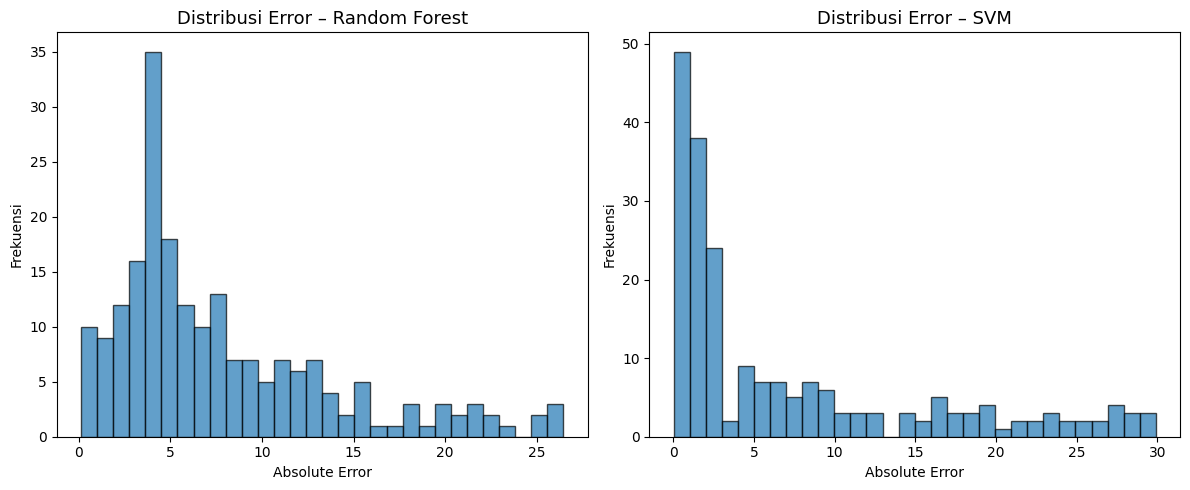

Gambar disimpan: distribusi_error.png


In [ ]:
# Hitung absolute error per data
error_rf  = np.abs(y_reg - pred_rf)
error_svm = np.abs(y_reg - pred_svm)

print('='*55)
print('STATISTIK ERROR')
print('='*55)
print(f'RF  - Mean: {error_rf.mean():.4f} | Std: {error_rf.std():.4f}')
print(f'SVM - Mean: {error_svm.mean():.4f} | Std: {error_svm.std():.4f}')

# Uji normalitas Shapiro-Wilk
# Shapiro-Wilk akurat untuk n < 5000
# Jika data > 5000, gunakan subsample
n = min(len(error_rf), 5000)
np.random.seed(42)
idx = np.random.choice(len(error_rf), n, replace=False)

stat_rf,  p_rf  = stats.shapiro(error_rf.iloc[idx])
stat_svm, p_svm = stats.shapiro(error_svm.iloc[idx])

print('\n' + '='*55)
print('UJI NORMALITAS – SHAPIRO-WILK')
print('='*55)
print(f'RF  - Statistik: {stat_rf:.4f} | p-value: {p_rf:.6f}')
print(f'SVM - Statistik: {stat_svm:.4f} | p-value: {p_svm:.6f}')
print()
if p_rf > 0.05:
    print('RF  → Distribusi NORMAL (p > 0.05)')
else:
    print('RF  → Distribusi TIDAK NORMAL (p < 0.05)')
if p_svm > 0.05:
    print('SVM → Distribusi NORMAL (p > 0.05)')
else:
    print('SVM → Distribusi TIDAK NORMAL (p < 0.05)')

if p_rf > 0.05 and p_svm > 0.05:
    print('\n→ Kedua distribusi normal → Gunakan UJI-T')
else:
    print('\n→ Salah satu/keduanya tidak normal → Gunakan MANN-WHITNEY U')

# Visualisasi distribusi error
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, error, title in zip(
    axes,
    [error_rf, error_svm],
    ['Random Forest', 'SVM']
):
    ax.hist(error, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribusi Error – {title}', fontsize=13)
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('distribusi_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: distribusi_error.png')

## SEL 4 – Uji statistik (uji-t atau Mann-Whitney)

In [ ]:
print('='*55)
print('UJI STATISTIK PERBANDINGAN RF vs SVM')
print('='*55)

if p_rf > 0.05 and p_svm > 0.05:
    # Kedua normal → uji-t independen
    print('Metode: UJI-T INDEPENDEN (Welch t-test)')
    print('Hipotesis:')
    print('  H0: Tidak ada perbedaan signifikan error RF dan SVM')
    print('  H1: Terdapat perbedaan signifikan error RF dan SVM')
    print()
    t_stat, p_value = stats.ttest_ind(error_rf, error_svm, equal_var=False)
    print(f'Statistik t : {t_stat:.4f}')
    print(f'p-value     : {p_value:.6f}')
else:
    # Tidak normal → Mann-Whitney U
    print('Metode: MANN-WHITNEY U')
    print('Hipotesis:')
    print('  H0: Tidak ada perbedaan signifikan error RF dan SVM')
    print('  H1: Terdapat perbedaan signifikan error RF dan SVM')
    print()
    u_stat, p_value = stats.mannwhitneyu(error_rf, error_svm, alternative='two-sided')
    print(f'Statistik U : {u_stat:.4f}')
    print(f'p-value     : {p_value:.6f}')

print()
ALPHA = 0.05
if p_value < ALPHA:
    print(f'Kesimpulan: p-value ({p_value:.6f}) < α ({ALPHA})')
    print('→ H0 DITOLAK: Terdapat perbedaan yang SIGNIFIKAN')
    print('  antara error prediksi RF dan SVM')
else:
    print(f'Kesimpulan: p-value ({p_value:.6f}) > α ({ALPHA})')
    print('→ H0 DITERIMA: Tidak terdapat perbedaan yang signifikan')
    print('  antara error prediksi RF dan SVM')

UJI STATISTIK PERBANDINGAN RF vs SVM
Metode: MANN-WHITNEY U
Hipotesis:
  H0: Tidak ada perbedaan signifikan error RF dan SVM
  H1: Terdapat perbedaan signifikan error RF dan SVM

Statistik U : 26541.0000
p-value     : 0.000026

Kesimpulan: p-value (0.000026) < α (0.05)
→ H0 DITOLAK: Terdapat perbedaan yang SIGNIFIKAN
  antara error prediksi RF dan SVM


## SEL 5 – Visualisasi perbandingan error RF vs SVM

/tmp/ipykernel_11481/1275212873.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([error_rf, error_svm], labels=['Random Forest', 'SVM'])
/tmp/ipykernel_11481/1275212873.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='Model', y='Error',


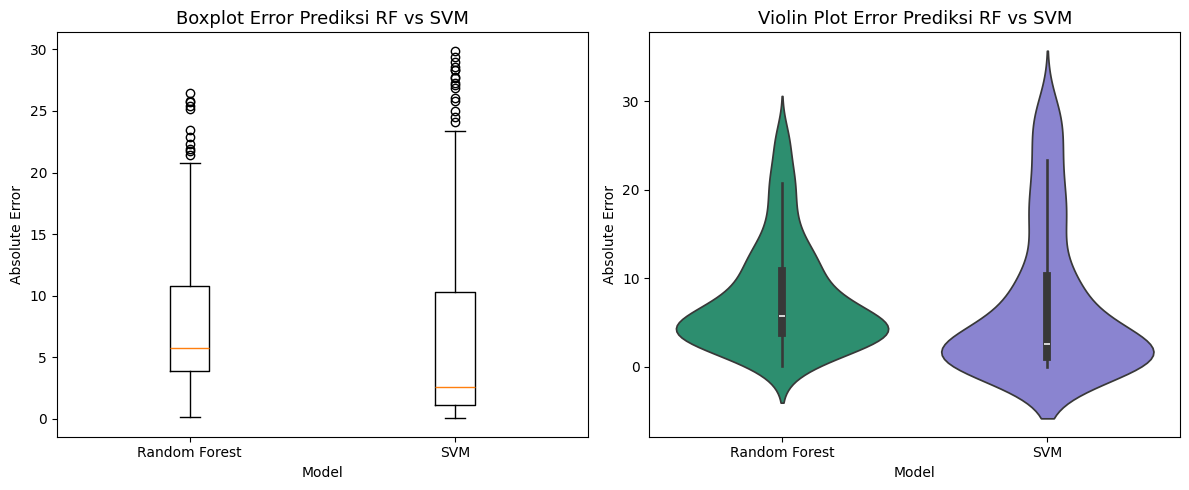

Gambar disimpan: perbandingan_error_statistik.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot perbandingan error
ax1 = axes[0]
ax1.boxplot([error_rf, error_svm], labels=['Random Forest', 'SVM'])
ax1.set_title('Boxplot Error Prediksi RF vs SVM', fontsize=13)
ax1.set_ylabel('Absolute Error')
ax1.set_xlabel('Model')

# Violin plot
ax2 = axes[1]
data_plot = pd.DataFrame({
    'Error': pd.concat([error_rf, error_svm], ignore_index=True),
    'Model': ['Random Forest']*len(error_rf) + ['SVM']*len(error_svm)
})
sns.violinplot(data=data_plot, x='Model', y='Error',
               palette=['#1D9E75', '#7F77DD'], ax=ax2)
ax2.set_title('Violin Plot Error Prediksi RF vs SVM', fontsize=13)
ax2.set_ylabel('Absolute Error')

plt.tight_layout()
plt.savefig('perbandingan_error_statistik.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: perbandingan_error_statistik.png')